##### Copyright 2026 Google LLC.

In [26]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

## Grounding using Search as a tool

<a target="_blank" href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Search_Grounding.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" height=30/></a>

In this notebook you will learn how to use the new Google Search tool available in the [Gemini](https://ai.google.dev/gemini-api/docs/models/gemini-v2) models, using both the unary API and the Multimodal Live API. Check out the docs to learn more about using [Search as a tool](https://ai.google.dev/gemini-api/docs/models/gemini-v2#search-tool).

Note that the previous version of this guide using Gemini models priori to 2.0 and the legacy SDK can still be found [here](https://github.com/google-gemini/cookbook/blob/gemini-1.5-archive/quickstarts/Search_Grounding.ipynb).

> **Note:** This notebook uses the [Interactions API](https://ai.google.dev/gemini-api/docs/interactions), the latest way to interact with Gemini models. Looking for the `generateContent` version? Check the [archive branch](https://github.com/google-gemini/cookbook/blob/archive/generate-content-api/quickstarts/Search_Grounding.ipynb).

## Set up the SDK and the client

### Install SDK

This guide uses the [`google-genai`](https://pypi.org/project/google-genai) Python SDK to connect to the Gemini models.

You'll find more details about the SDK on the [documentation](https://googleapis.github.io/python-genai/) or in the [Getting started](./Get_started.ipynb) notebook.

In [27]:
%pip install -U -q "google-genai>=2.9.0"  # 2.0 for Interactions API

### Set up your API key

To run the following cell, your API key must be stored in a Colab Secret named `GEMINI_API_KEY`. If you don't already have an API key, or you're not sure how to create a Colab Secret, see [Authentication](https://github.com/google-gemini/cookbook/blob/main/quickstarts/Authentication.ipynb) for a walkthrough.

In [28]:
import os
from google.colab import userdata

os.environ['GEMINI_API_KEY'] = userdata.get('GEMINI_API_KEY')

Select the model you want to use in this guide:

In [29]:
from google import genai

client = genai.Client() # the API key is automatically loaded from the environment variable

MODEL_ID = "gemini-3.5-flash" # @param ["gemini-3.1-flash-lite", "gemini-2.5-flash", "gemini-3.5-flash", "gemini-2.5-pro", "gemini-3-flash-preview", "gemini-3.1-pro-preview"] {"allow-input":true, isTemplate: true}

## Use Google Search
Search grounding is particularly useful for queries that require current information or external knowledge. Using Google Search, Gemini can access nearly real-time information and better responses.
> The response from `interactions.create` contains a list of `steps`. For text responses, access the output via `interaction.steps[-1].content[0].text` or `interaction.output_text`.


In [30]:
from IPython.display import display, HTML, Markdown

interaction = client.interactions.create(
    model=MODEL_ID,
    input='What was the latest Indian Premier League match and who won?',
)

# Print the text response
display(Markdown(interaction.output_text))


Because my knowledge is limited to January 2025 and I do not have access to real-time data or the live internet, I cannot provide the results of any IPL matches played after that time (such as those in the 2025 season). 

However, based on my latest available data, the final match of the **2024 Indian Premier League (IPL)** took place on **May 26, 2024**. 

* **Match:** Kolkata Knight Riders (KKR) vs. Sunrisers Hyderabad (SRH)
* **Winner:** **Kolkata Knight Riders (KKR)** won by 8 wickets to claim their third IPL title.

If you are looking for the results of a match played more recently in the ongoing or latest season, I recommend checking:
* The official IPL website (iplt20.com)
* Major sports news websites like ESPNcricinfo, Cricbuzz, or NDTV Sports.

The information provided may be outdated, as it is based on a knowledge cutoff. For the most current and authoritative details, please refer to the official [Model documentation](https://ai.google.dev/gemini-api/docs/models#gemini-2.5-pro), which includes the latest knowledge cutoff date.

You can see that running the same prompt **with** search grounding (enabled via `tools=[{"type": "google_search"}],`) gives you outdated information:

In [31]:
from IPython.display import display, Markdown

interaction = client.interactions.create(
    model=MODEL_ID,
    input='What was the latest Indian Premier League match and who won?',
    tools=[{"type": "google_search"}],
)

# Print the text response
display(Markdown(interaction.output_text))

The latest Indian Premier League (IPL) match was the **IPL 2026 Final**, which took place on **Sunday, May 31, 2026**. 

### **Match Details:**
* **Opponents:** Royal Challengers Bengaluru (RCB) vs. Gujarat Titans (GT)
* **Winner:** **Royal Challengers Bengaluru (RCB)** won by 5 wickets.
* **Venue:** Narendra Modi Stadium in Ahmedabad.

### **Scorecard Summary:**
* **Gujarat Titans (GT):** 155/8 (20 overs)
* **Royal Challengers Bengaluru (RCB):** 161/5 (18 overs)

### **Highlights:**
Virat Kohli led RCB to victory with a match-winning, unbeaten **75 runs off 42 balls**, sealing the title by hitting a six with 12 balls to spare. With this victory, RCB (captained by Rajat Patidar) successfully defended their championship, securing their second consecutive IPL title and joining Chennai Super Kings and Mumbai Indians as the only franchises to win back-to-back IPL crowns.

### Attributing the sources
You should always display the grounding `rendered_content` when using search grounding.

In [32]:
# Find each step with type "google_search_result"
for step in interaction.steps:
    if step.type == "google_search_result":
        # The result is a list, so we access the first element and display its HTML content
        display(HTML(step.result[0].search_suggestions))


You can also get all the sources so you can display them the way you want:

In [33]:
for step in interaction.steps:
    if step.type == "model_output":
        for content_block in step.content:
            if content_block.type == "text":
                print(content_block.text)
                if content_block.annotations:
                    print("\nCitations:")
                    for annotation in content_block.annotations:
                        if annotation.type == "url_citation":
                            cited_text = content_block.text[annotation.start_index:annotation.end_index]
                            print(f"  [{annotation.title}]({annotation.url})")
                            print(f"    Cited text: \"{cited_text}\"")

The latest Indian Premier League (IPL) match was the **IPL 2026 Final**, which took place on **Sunday, May 31, 2026**. 

### **Match Details:**
* **Opponents:** Royal Challengers Bengaluru (RCB) vs. Gujarat Titans (GT)
* **Winner:** **Royal Challengers Bengaluru (RCB)** won by 5 wickets.
* **Venue:** Narendra Modi Stadium in Ahmedabad.

### **Scorecard Summary:**
* **Gujarat Titans (GT):** 155/8 (20 overs)
* **Royal Challengers Bengaluru (RCB):** 161/5 (18 overs)

### **Highlights:**
Virat Kohli led RCB to victory with a match-winning, unbeaten **75 runs off 42 balls**, sealing the title by hitting a six with 12 balls to spare. With this victory, RCB (captained by Rajat Patidar) successfully defended their championship, securing their second consecutive IPL title and joining Chennai Super Kings and Mumbai Indians as the only franchises to win back-to-back IPL crowns.

Citations:
  [iplt20.com](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQE-5UwBuZioFPkw88X_Z-2IFu

## Use search in multiturn chat

First try a query that needs realtime information, so you can see how the model performs _without_ Google Search.

In [34]:
turn_1 = client.interactions.create(
    model=MODEL_ID,
    input='Who won the most recent Australian Open?',
)


display(Markdown(interaction.output_text))

The latest Indian Premier League (IPL) match was the **IPL 2026 Final**, which took place on **Sunday, May 31, 2026**. 

### **Match Details:**
* **Opponents:** Royal Challengers Bengaluru (RCB) vs. Gujarat Titans (GT)
* **Winner:** **Royal Challengers Bengaluru (RCB)** won by 5 wickets.
* **Venue:** Narendra Modi Stadium in Ahmedabad.

### **Scorecard Summary:**
* **Gujarat Titans (GT):** 155/8 (20 overs)
* **Royal Challengers Bengaluru (RCB):** 161/5 (18 overs)

### **Highlights:**
Virat Kohli led RCB to victory with a match-winning, unbeaten **75 runs off 42 balls**, sealing the title by hitting a six with 12 balls to spare. With this victory, RCB (captained by Rajat Patidar) successfully defended their championship, securing their second consecutive IPL title and joining Chennai Super Kings and Mumbai Indians as the only franchises to win back-to-back IPL crowns.

Now let try another interactions that uses the `google_search` tool.  The `show_parts` helper will display the text output as well as any Google Search queries used in the results.

In [35]:
search_turn_1 = client.interactions.create(
    model=MODEL_ID,
    input='Who won the most recent Australian Open?',
    tools=[{"type": "google_search"}],
)

display(Markdown(search_turn_1.output_text))

The most recent Australian Open took place from January 18 to February 1, 2026. The winners of the main events were:

### **Singles Championships**
* **Men's Singles:** **Carlos Alcaraz** (Spain) won his first Australian Open title by defeating Novak Djokovic in the final (2–6, 6–2, 6–3, 7–5). With this victory, Alcaraz became the youngest man in tennis history to complete the Career Grand Slam.
* **Women's Singles:** **Elena Rybakina** (Kazakhstan) won her first Australian Open title, defeating Aryna Sabalenka in a tight three-set final (6–4, 4–6, 6–4). 

### **Doubles Championships**
* **Men's Doubles:** **Christian Harrison** (USA) and **Neal Skupski** (UK) defeated the Australian duo of Jason Kubler and Marc Polmans (7–6(4), 6–4). 
* **Women's Doubles:** **Elise Mertens** (Belgium) and **Zhang Shuai** (China) defeated Anna Danilina and Aleksandra Krunić (7–6(4), 6–4).
* **Mixed Doubles:** The Australian pair **Olivia Gadecki** and **John Peers** successfully defended their title, defeating Kristina Mladenovic and Manuel Guinard (4–6, 6–3, [10–8]).

You can continue the dicussion by passing the interaction's `id` and the model will remember what has happend before, including the tool call so you don't need to make a search call again.

In [36]:
search_turn_2 = client.interactions.create(
    model=MODEL_ID,
    input='Who lost during the final?',
    previous_interaction_id=search_turn_1.id,
)

display(Markdown(search_turn_2.output_text))

Here are the runners-up (those who lost in the finals) of the 2026 Australian Open:

### **Singles Finals**
* **Men's Singles Runner-Up:** **Novak Djokovic** (Serbia), who lost to Carlos Alcaraz.
* **Women's Singles Runner-Up:** **Aryna Sabalenka** (Belarus), who lost to Elena Rybakina.

### **Doubles Finals**
* **Men's Doubles Runners-Up:** **Jason Kubler** and **Marc Polmans** (both from Australia), who lost to Christian Harrison and Neal Skupski.
* **Women's Doubles Runners-Up:** **Anna Danilina** (Kazakhstan) and **Aleksandra Krunić** (Serbia), who lost to Elise Mertens and Zhang Shuai.
* **Mixed Doubles Runners-Up:** **Kristina Mladenovic** (France) and **Manuel Guinard** (France), who lost to Olivia Gadecki and John Peers.

## Plot search results


In this example you can see how to use the Google Search tool with code generation in order to plot results.

In [37]:
movie_turn_1 = client.interactions.create(
    model=MODEL_ID,
    input='Search the web and list the top 5 grossing movies in 2024 and their worldwide revenue in USD? Also provide the code to plot this as a bar chart using matplotlib.',
    tools=[{"type": "google_search"}],
)

for step in movie_turn_1.steps:
    if step.type == "model_output":
        display(Markdown(step.content[0].text))

According to Box Office Mojo and Wikipedia, the top 5 highest-grossing movies released in 2024 and their worldwide revenues in USD are:

1. **Inside Out 2** – **$1,698,863,816**
2. **Deadpool & Wolverine** – **$1,338,073,645**
3. **Moana 2** – **$1,059,242,164**
4. **Despicable Me 4** – **$972,015,095**
5. **Wicked** – **$758,729,195**

*(Note: These totals reflect the full theatrical runs of these 2024 releases, including earnings that carried over into 2025.)*

---

### Python Code (Matplotlib) to Plot the Bar Chart

Below is the Python code using the `matplotlib` library to plot a horizontal bar chart of this data. For ease of readability, the values are scaled to **billions of dollars**.

```python
import matplotlib.pyplot as plt

# Data for the top 5 highest-grossing movies of 2024
movies = [
    "Inside Out 2",
    "Deadpool & Wolverine",
    "Moana 2",
    "Despicable Me 4",
    "Wicked"
]

# Exact worldwide revenues in USD
revenues_usd = [
    1698863816,
    1338073645,
    1059242164,
    972015095,
    758729195
]

# Convert revenues to billions of USD for a cleaner chart display
revenues_billions = [rev / 1e9 for rev in revenues_usd]

# Choose a cohesive color palette
colors = ['#0f4c5c', '#e36414', '#fb8b24', '#5f0f40', '#9a031e']

# Set the figure size
plt.figure(figsize=(11, 6))

# Create vertical bar chart
bars = plt.bar(movies, revenues_billions, color=colors, edgecolor='black', width=0.6)

# Add value labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0, 
        yval + 0.03, 
        f"${yval:.3f}B", 
        ha='center', 
        va='bottom', 
        fontweight='bold', 
        fontsize=10
    )

# Formatting labels and title
plt.title('Top 5 Highest-Grossing Movies of 2024 (Worldwide)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Movie Title', fontsize=12, labelpad=10)
plt.ylabel('Worldwide Revenue (in Billions USD)', fontsize=12, labelpad=10)

# Adjust y-limit to leave space for labels on top of the bars
plt.ylim(0, 2.0)

# Add gridlines for the y-axis
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Render layout nicely
plt.tight_layout()

# Display the plot
plt.show()
```

First review the supplied code to make sure it does what you expect, then copy it here to try out the chart.

In [38]:
import re

text = next((step.content[0].text for step in movie_turn_1.steps if step.type == "model_output"), "")
matchFound = re.search(r"python\n(.*?)```", text, re.DOTALL)
print(matchFound.group(1))

import matplotlib.pyplot as plt

# Data for the top 5 highest-grossing movies of 2024
movies = [
    "Inside Out 2",
    "Deadpool & Wolverine",
    "Moana 2",
    "Despicable Me 4",
    "Wicked"
]

# Exact worldwide revenues in USD
revenues_usd = [
    1698863816,
    1338073645,
    1059242164,
    972015095,
    758729195
]

# Convert revenues to billions of USD for a cleaner chart display
revenues_billions = [rev / 1e9 for rev in revenues_usd]

# Choose a cohesive color palette
colors = ['#0f4c5c', '#e36414', '#fb8b24', '#5f0f40', '#9a031e']

# Set the figure size
plt.figure(figsize=(11, 6))

# Create vertical bar chart
bars = plt.bar(movies, revenues_billions, color=colors, edgecolor='black', width=0.6)

# Add value labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0, 
        yval + 0.03, 
        f"${yval:.3f}B", 
        ha='center', 
        va='bottom', 
        fontweight='bold', 
        fontsize=1

One feature of using a chat conversation to do this is that you can now ask the model to make changes.

In [39]:
movie_turn_2 = client.interactions.create(
    model=MODEL_ID,
    input='Looks great! Can you give the chart a dark theme instead?',
    previous_interaction_id=movie_turn_1.id,
    tools=[{"type": "google_search"}],
)

for step in movie_turn_2.steps:
    if step.type == "model_output":
        display(Markdown(step.content[0].text))

Here is the updated Python code featuring a sleek, modern dark theme. 

To achieve this, the code utilizes Matplotlib's `'dark_background'` style preset, applies a dark off-black background (`#121212`), removes unnecessary outer borders (spines) for a cleaner look, and uses a vibrant neon-inspired color palette to make the bars stand out:

```python
import matplotlib.pyplot as plt

# Use matplotlib's built-in dark background style as a baseline
plt.style.use('dark_background')

# Data
movies = [
    "Inside Out 2",
    "Deadpool & Wolverine",
    "Moana 2",
    "Despicable Me 4",
    "Wicked"
]

revenues_usd = [
    1698863816,
    1338073645,
    1059242164,
    972015095,
    758729195
]

# Convert to Billions USD
revenues_billions = [rev / 1e9 for rev in revenues_usd]

# Vibrant neon/bright color palette that pops against dark backgrounds
colors = [
    '#00b4d8',  # Neon Teal (Inside Out 2)
    '#e63946',  # Crimson Red (Deadpool & Wolverine)
    '#ffb703',  # Sunset Orange/Yellow (Moana 2)
    '#9d4edd',  # Electric Purple (Despicable Me 4)
    '#70e000'   # Acid Green (Wicked)
]

# Set up the figure with a sleek off-black background
fig = plt.figure(figsize=(11, 6), facecolor='#121212')
ax = plt.axes()
ax.set_facecolor('#121212')

# Create the vertical bar chart
bars = ax.bar(movies, revenues_billions, color=colors, edgecolor='white', linewidth=0.5, width=0.55)

# Add value labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0, 
        yval + 0.04, 
        f"${yval:.3f}B", 
        ha='center', 
        va='bottom', 
        fontweight='semibold', 
        fontsize=10,
        color='white'
    )

# Formatting title and labels
ax.set_title('Top 5 Highest-Grossing Movies of 2024 (Worldwide)', fontsize=16, fontweight='bold', pad=20, color='white')
ax.set_xlabel('Movie Title', fontsize=12, labelpad=10, color='#e0e0e0')
ax.set_ylabel('Worldwide Revenue (in Billions USD)', fontsize=12, labelpad=10, color='#e0e0e0')

# Style the ticks
ax.tick_params(colors='#e0e0e0', labelsize=10)

# Adjust y-limit
ax.set_ylim(0, 2.0)

# Subtle, faint gridlines to avoid cluttering the dark theme
ax.grid(axis='y', linestyle='--', alpha=0.15, color='white')

# Clean up spines (borders) for a more modern flat look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

# Render layout nicely
plt.tight_layout()

# Display the plot
plt.show()
```

Again, always be sure to review code generated by the model before running it.

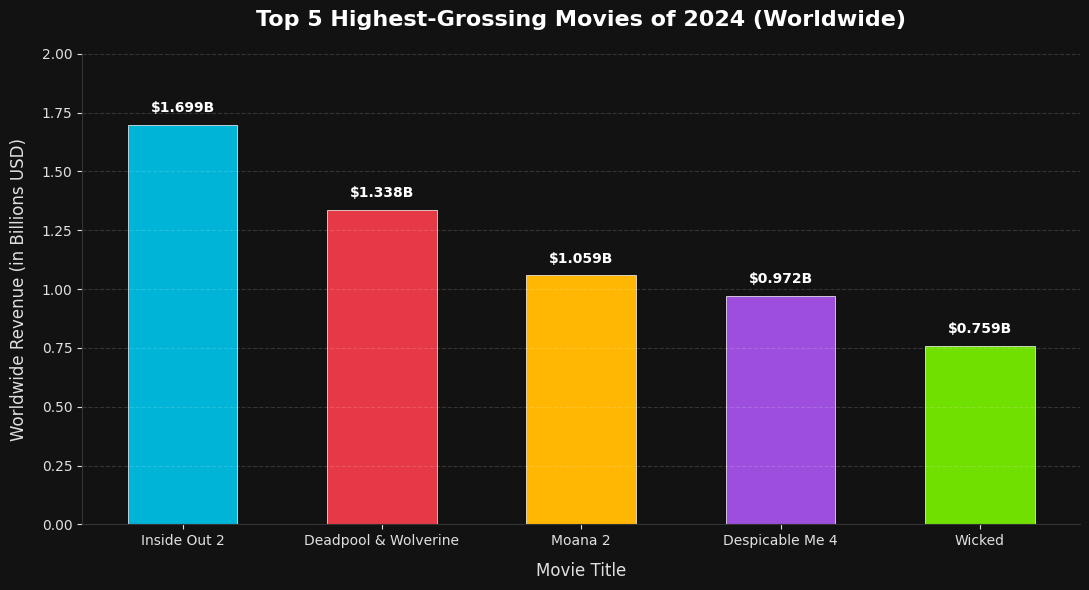

In [40]:
import re

text = next((step.content[0].text for step in movie_turn_2.steps if step.type == "model_output"), "")
matchFound = re.search(r"python\n(.*?)```", text, re.DOTALL)

if matchFound:
    code = matchFound.group(1)
    exec(code)

## Use search in the Multimodal Live API

The Search tool can be used in a live streaming context to have the model formulate grounded responses during the conversation.

In [41]:
LIVE_MODEL_ID = 'gemini-2.5-flash-native-audio-preview-09-2025'  # @param ['gemini-2.0-flash-live-001', 'gemini-live-2.5-flash-preview', 'gemini-2.5-flash-native-audio-preview-09-2025'] {allow-input: true, isTemplate: true}

### Define some helpers

To use the bi-directional streaming API in Colab, you will buffer the audio stream. Define a `play_response` helper function to do the buffering, and once the audio for the current turn has completed, display an IPython audio widget.

As each of the following examples only use a single prompt, also define a `run` helper to wrap the setup and prompt execution steps into a single function call. This helper takes a `config` argument that will be added to the `generation_config`, so that you can toggle the Search tool between examples.

In [42]:
# @title Helper functions for the Live API (run this cell)

import asyncio
import io
import json
import re
import time
import wave

import numpy as np
from IPython.display import Audio, display


DEFAULT_OUTPUT_RATE = 24000
BASE_MODEL_CONFIG = {
    # Here you can change the model's output mode between either audio or text.
    # While this code expects an audio stream, text should work, but the stream
    # may interleave with the `Buffering....` text.
    'response_modalities': ['AUDIO']
}

async def play_response(stream):
  """Buffer audio output and display a widget. Returns the streamed responses."""
  turn_buf = io.BytesIO()
  sample_rate = DEFAULT_OUTPUT_RATE

  all_responses = []

  print('Buffering', end='')
  async for msg in stream.receive():
    all_responses.append(msg)

    if audio_data := msg.data:  # This is what triggers the warnings, use the full path to access the audio data
      turn_buf.write(audio_data)
      if m := re.search(
          r'rate=(?P<rate>\d+)',
          msg.server_content.model_turn.parts[0].inline_data.mime_type
      ):
            sample_rate = int(m.group('rate'))

    elif tool_call := msg.tool_call:
      # Handle tool-call requests. Here is where you would implement
      # custom tool code, but for this example, all tools respond 'ok'.
      for fc in tool_call.function_calls:
        print('Tool call', end='')
        tool_response = genai.types.LiveClientToolResponse(
            function_responses=[genai.types.FunctionResponse(
                name=fc.name,
                id=fc.id,
                response={'result': 'ok'},
            )]
        )
        await stream.send(input=tool_response)

    print('.', end='')

  print()

  # Play the audio
  if turn_buf.tell():
    audio = np.frombuffer(turn_buf.getvalue(), dtype=np.int16)
    display(Audio(audio, autoplay=True, rate=sample_rate))
  else:
    print('No audio :(')
    print(f'  {len(all_responses)=}')

  return all_responses


async def run(query, config=None):
  # Add any tools or other generation config.
  config = BASE_MODEL_CONFIG | (config or {})

  # Establish a live session. While this context manager is active, the
  # conversation will continue.
  async with client.aio.live.connect(model=LIVE_MODEL_ID, config=config) as strm:

    # Send the prompt.
    await strm.send(input=query, end_of_turn=True)
    # Handle the model response.
    responses = await play_response(strm)

    return responses

### Stream with the Search tool

First, execute a query _without_ the Search tool to observe the model's response to a time-sensitive query.

Note that the Multimodal Live API is a 2-way streaming API, but to simplify running in a notebook, each audio response is buffered and played once it has been fully streamed, so you will need to wait a few seconds before the response starts to play.

In [43]:
await run('Who won the skateboarding gold medals in the 2024 olympics?');

/tmp/ipykernel_1870/3682019348.py:79: DeprecationWarning: The `session.send` method is deprecated and will be removed in a future version (not before Q3 2025).
Please use one of the more specific methods: `send_client_content`, `send_realtime_input`, or `send_tool_response` instead.
  await strm.send(input=query, end_of_turn=True)


Buffering.....................................................................................................................................................................................................................................................................................................................................................................................


Now re-run with the Search tool enabled.

In [44]:
search_tool = {"google_search": {}}

responses = await run('Who won the skateboarding gold medals in the 2024 olympics?', {'tools': [search_tool]})


/tmp/ipykernel_1870/3682019348.py:79: DeprecationWarning: The `session.send` method is deprecated and will be removed in a future version (not before Q3 2025).
Please use one of the more specific methods: `send_client_content`, `send_realtime_input`, or `send_tool_response` instead.
  await strm.send(input=query, end_of_turn=True)


Buffering...............................................................................................................................................................................................................................................................................................................................................................................................................................


If you wish to see the full output that was returned, you can enable `show_output` here and run this cell. It includes the complete audio binary data, so it is off by default.

In [45]:
show_output = False

if show_output:
  for msg in responses:
    print(msg.model_dump(exclude_none=True))

## Next steps

<a name="next_steps"></a>

Search grounding is not the only way to ground your requests, you can also use YouTube links and URL context. Check the [Grounding](./Grounding.ipynb) guide for more info on those capabilities.

* For more demos showcasing multi-tool use in the Multimodal Live API, check out the [Plotting and Mapping cookbook](../examples/LiveAPI_plotting_and_mapping.ipynb).
* To get started with the Live API with the Python SDK, check out the [starter guide](./Get_started_LiveAPI.ipynb).
* To learn more about tool use in the Live API, check out the [Live API Tool Use cookbook](./Get_started_LiveAPI_tools.ipynb).

Also check the other Gemini advanced capabilities (like [spatial understanding](../quickstarts/Spatial_understanding.ipynb)) that you can find in the [Gemini Cookbook](https://github.com/google-gemini/cookbook/tree/main/gemini-2/).